# 주제 ④ X-ray — 데이터 품질 진단

모델링 없음. 목적은 주제 선정을 위한 1차 EDA. 표기: 확정 사실은 그대로, 간접 근거는 **(추정)** 으로 표시한다.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import data_quality as dq

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore")

RAW_DIR = ROOT / "data_raw"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
print("ROOT resolved:", ROOT.name, "/ topics 폴더 기준 상대 실행 확인 완료")


ROOT resolved: 04_xray / topics 폴더 기준 상대 실행 확인 완료


## 0. 사전 확인

In [2]:
if not (RAW_DIR / "raw_bmp" / "index.csv").exists():
    import subprocess
    subprocess.run([sys.executable, str(ROOT / "src" / "extract.py")], check=True)

index_df = dq.load_index(ROOT)
print("index.csv rows:", len(index_df))
n_dup_stem = int(index_df["stem"].duplicated().sum())
print("호기 간 겹치는 파일명 스템 수:", n_dup_stem)
# 위 3건은 서로 다른 호기 폴더에서 우연히 같은 파일명이 나온 경우(README 기록).
# stem -> 값 조회는 중복 없는 버전을 쓴다(첫 항목 채택, 값은 파일명 파생값이라 동일).
stem_first = index_df.drop_duplicates(subset="stem", keep="first").set_index("stem")
index_df.head(3)


index.csv rows: 2532
호기 간 겹치는 파일명 스템 수: 3


,basename,machine,serial,folder_date,filename_date,filename_time,n_copies,size,crc,crc_conflict,stem,burst,date,hour
0,002_20200622_203053(2).bmp,machine_1,SN77128,20200622,20200622,203053,2,117942,3633657820,0,002_20200622_203053(2),2,2020-06-22,20
1,002_20200622_203057(3).bmp,machine_1,SN77128,20200622,20200622,203057,2,117942,3616139433,0,002_20200622_203057(3),3,2020-06-22,20
2,002_20200622_203101(3).bmp,machine_1,SN77128,20200622,20200622,203101,2,117942,1568554166,0,002_20200622_203101(3),3,2020-06-22,20


In [3]:
label_summary, label_boxes = dq.parse_yolo_labels(ROOT)
label_stems = set(label_summary["stem"])
print("라벨(txt) 파일 수:", len(label_summary))


라벨(txt) 파일 수: 500


## 1. 영상 메타 진단 (`scan_images`)

In [4]:
raw_paths = dq.raw_bmp_paths(ROOT)
labeled_paths = dq.labeled_image_paths(ROOT)
print("raw bmp:", len(raw_paths), " labeled jpg:", len(labeled_paths))

scan_raw = dq.scan_images(raw_paths)
scan_labeled = dq.scan_images(labeled_paths)
scan_raw["machine"] = scan_raw["path"].str.extract(r"(machine_\d)")
print("깨진 파일(raw):", int(scan_raw["corrupted"].sum()), " 깨진 파일(labeled):", int(scan_labeled["corrupted"].sum()))


raw bmp: 2532  labeled jpg: 400


깨진 파일(raw): 0  깨진 파일(labeled): 0


In [5]:
res_table = scan_raw.groupby(["machine", "width", "height", "mode"]).size().rename("n_files").reset_index()
res_table


,machine,width,height,mode,n_files
0,machine_1,316,332,P,431
1,machine_1,352,332,P,392
2,machine_1,412,332,P,120
3,machine_2,316,332,P,805
4,machine_3,576,444,P,784


In [6]:
size_by_machine = index_df.groupby("machine")["size"].agg(["count", "mean", "std", "min", "max"]).round(1)
size_by_machine


,count,mean,std,min,max
machine,,,,,
machine_1,943,115014.2,10359.9,105990,137862
machine_2,805,105990.0,0.0,105990,105990
machine_3,784,256822.0,0.0,256822,256822


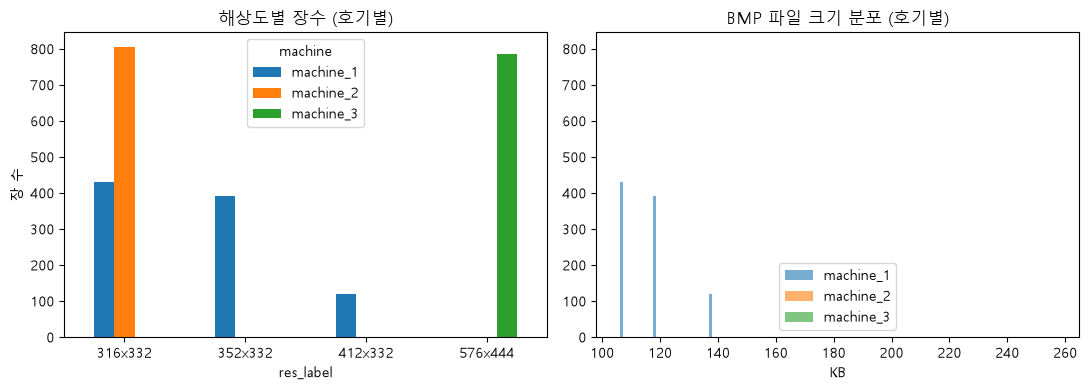

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
res_table["res_label"] = res_table["width"].astype(str) + "x" + res_table["height"].astype(str)
piv = res_table.pivot_table(index="res_label", columns="machine", values="n_files", fill_value=0)
piv.plot(kind="bar", ax=axes[0])
axes[0].set_title("해상도별 장수 (호기별)")
axes[0].set_ylabel("장 수")
axes[0].tick_params(axis="x", rotation=0)

for m, g in index_df.groupby("machine"):
    axes[1].hist(g["size"] / 1000, bins=30, alpha=0.6, label=m)
axes[1].set_title("BMP 파일 크기 분포 (호기별)")
axes[1].set_xlabel("KB")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_meta_resolution.png", dpi=120)
plt.show()


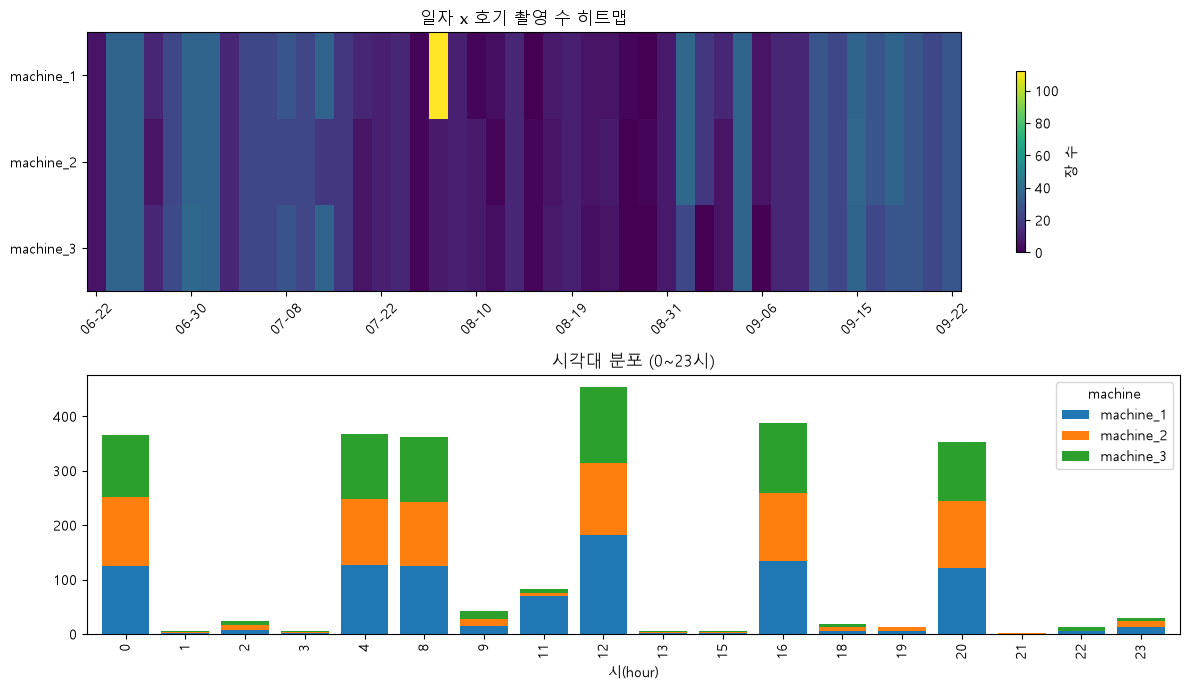

In [8]:
timeline = index_df.groupby(["machine", "date"]).size().unstack("machine", fill_value=0)
hour_dist = index_df.groupby(["machine", "hour"]).size().unstack("machine", fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
im = axes[0].imshow(timeline.T, aspect="auto", cmap="viridis")
axes[0].set_yticks(range(len(timeline.columns)))
axes[0].set_yticklabels(timeline.columns)
xt = np.linspace(0, len(timeline.index) - 1, min(10, len(timeline.index))).astype(int)
axes[0].set_xticks(xt)
axes[0].set_xticklabels([timeline.index[i].strftime("%m-%d") for i in xt], rotation=45)
axes[0].set_title("일자 x 호기 촬영 수 히트맵")
fig.colorbar(im, ax=axes[0], shrink=0.7, label="장 수")

hour_dist.plot(kind="bar", stacked=True, ax=axes[1], width=0.8)
axes[1].set_title("시각대 분포 (0~23시)")
axes[1].set_xlabel("시(hour)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_capture_timeline.png", dpi=120)
plt.show()


In [9]:
# 연사(같은 초 스템) 그룹 크기
same_second = index_df.groupby(["machine", "filename_date", "filename_time"]).size()
print("같은 호기+날짜+HHMMSS 그룹 수:", len(same_second), " / 그룹 크기 분포:")
print(same_second.value_counts().sort_index())

# 같은 호기·날짜 안에서 정렬한 인접 촬영 시간 간격(초)
t = pd.to_datetime(index_df["filename_date"] + index_df["filename_time"], format="%Y%m%d%H%M%S")
gaps = t.groupby([index_df["machine"], index_df["filename_date"]]).apply(
    lambda s: s.sort_values().diff().dt.total_seconds().dropna()
)
print("\n인접 촬영 시간 간격(초) 분포:")
print(gaps.describe())
print("\n파일명 끝자리 (k) 값 분포:")
print(index_df["burst"].value_counts().sort_index())


같은 호기+날짜+HHMMSS 그룹 수: 2530  / 그룹 크기 분포:
1    2528
2       2
Name: count, dtype: int64

인접 촬영 시간 간격(초) 분포:
count     2401.000000
mean      2244.685964
std       5473.196667
min          0.000000
25%          4.000000
50%          4.000000
75%          9.000000
max      66565.000000
dtype: float64

파일명 끝자리 (k) 값 분포:
burst
0    277
1    219
2    284
3    263
4    244
5    245
6    235
7    277
8    259
9    229
Name: count, dtype: Int64


## 2. 픽셀 강도 진단 (`intensity_stats`)

In [10]:
intensity = dq.intensity_stats(raw_paths)
intensity["machine"] = intensity["path"].str.extract(r"(machine_\d)")
intensity["stem"] = intensity["name"].str.replace(".bmp", "", regex=False)
intensity["date"] = intensity["stem"].map(stem_first["date"])
intensity.groupby("machine")[["mean", "std", "min", "max", "marker_frac"]].agg(["mean", "std"]).round(3)


mean            std            min            max      marker_frac       
              mean    std    mean    std    mean     std   mean  std        mean    std
machine                                                                                
machine_1  195.173  3.357  27.661  4.748  62.533  24.707  213.0  0.0       0.002  0.001
machine_2  183.742  1.445  43.791  1.429  34.668   3.876  213.0  0.0       0.002  0.001
machine_3  193.310  0.626  34.012  1.414  43.186   5.602  210.0  0.0       0.001  0.001

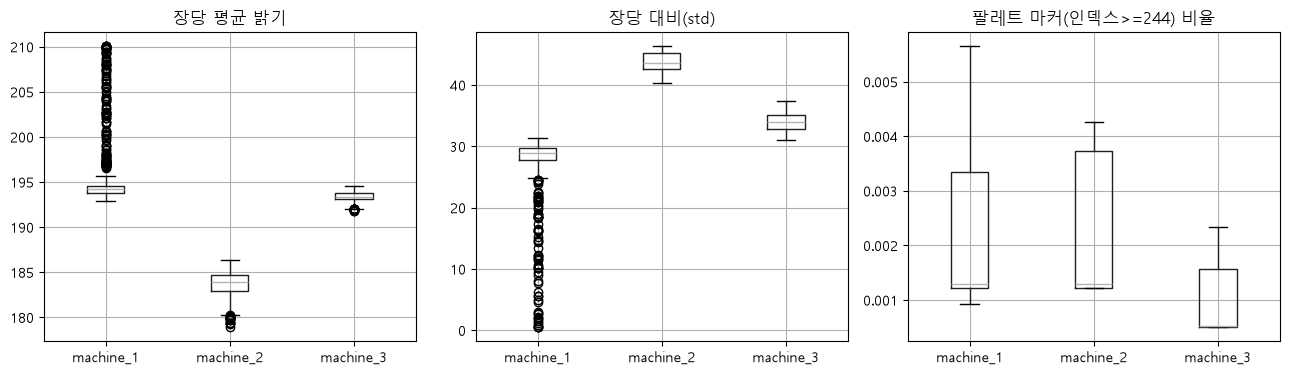

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
intensity.boxplot(column="mean", by="machine", ax=axes[0])
axes[0].set_title("장당 평균 밝기")
intensity.boxplot(column="std", by="machine", ax=axes[1])
axes[1].set_title("장당 대비(std)")
intensity.boxplot(column="marker_frac", by="machine", ax=axes[2])
axes[2].set_title("팔레트 마커(인덱스>=244) 비율")
for ax in axes:
    ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_intensity_by_machine.png", dpi=120)
plt.show()


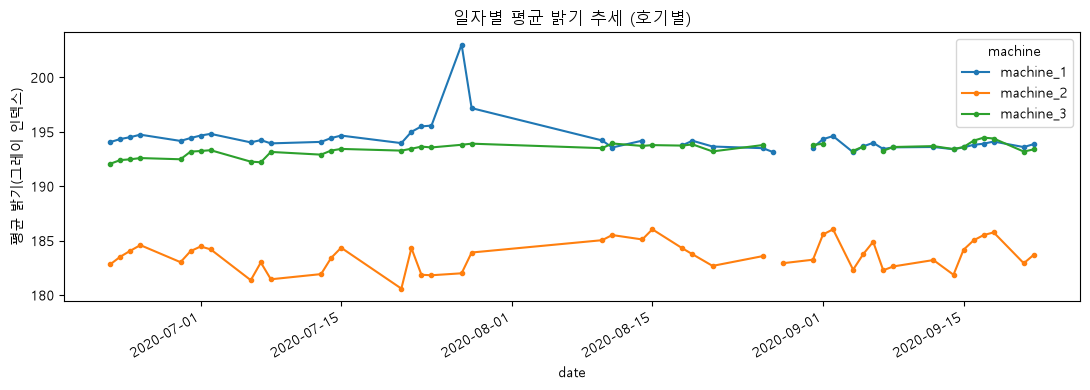

In [12]:
daily = intensity.groupby(["machine", "date"])["mean"].mean().unstack("machine")
fig, ax = plt.subplots(figsize=(11, 4))
daily.plot(ax=ax, marker=".")
ax.set_title("일자별 평균 밝기 추세 (호기별)")
ax.set_ylabel("평균 밝기(그레이 인덱스)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_intensity_drift.png", dpi=120)
plt.show()


In [13]:
extreme = intensity[(intensity["std"] < 5) | (intensity["mean"] < 100) | (intensity["mean"] > 250)]
print("극단 밝기/대비 영상 수:", len(extreme))
extreme[["name", "machine", "mean", "std"]].head(10)


극단 밝기/대비 영상 수: 15


,name,machine,mean,std
399,002_20200727_111038(1).bmp,machine_1,209.940312,1.575157
405,002_20200727_111648(3).bmp,machine_1,209.899614,1.922431
410,002_20200727_112148(2).bmp,machine_1,209.870640,2.117503
411,002_20200727_112242(2).bmp,machine_1,209.994740,1.146655
419,002_20200727_112930(2).bmp,machine_1,209.787135,2.689906
420,002_20200727_112943(7).bmp,machine_1,209.760983,2.843068
432,002_20200727_114126(2).bmp,machine_1,209.886692,1.978604
440,002_20200727_115040(1).bmp,machine_1,209.457135,4.613466
448,002_20200727_115526(5).bmp,machine_1,210.042226,0.491735
457,002_20200727_120134(0).bmp,machine_1,210.040110,0.528527


## 3. BMP <-> 라벨 JPG 비교 (`bmp_jpg_psnr`)

In [14]:
magic = {p.name: open(p, "rb").read(2) for p in labeled_paths[:5]}
print("라벨 JPG 파일의 실제 매직바이트(앞 2바이트):", {k: v for k, v in magic.items()})

psnr_df = dq.bmp_jpg_psnr(ROOT)
print("has_bmp 전부 True:", bool(psnr_df["has_bmp"].all()))
print("size_match 전부 True:", bool(psnr_df["size_match"].all()))
print("PSNR 무한대(완전 일치) 비율:", float(np.isinf(psnr_df["psnr"]).mean()))
psnr_df["psnr"].describe()


라벨 JPG 파일의 실제 매직바이트(앞 2바이트): {'001_20200622_203305(8).jpg': b'BM', '001_20200622_203309(1).jpg': b'BM', '001_20200622_203312(6).jpg': b'BM', '001_20200622_203316(0).jpg': b'BM', '001_20200622_203319(4).jpg': b'BM'}


has_bmp 전부 True: True
size_match 전부 True: True
PSNR 무한대(완전 일치) 비율: 1.0


count    400.0
mean       inf
std        NaN
min        inf
25%        NaN
50%        NaN
75%        NaN
max        inf
Name: psnr, dtype: float64

## 4. 라벨 파싱·형식 검증 (`parse_yolo_labels`, `parse_voc_xml`)

In [15]:
print("txt 라벨:", len(label_summary), " / 형식 오류 합:", int(label_summary["n_format_errors"].sum()))
print("이미지당 bbox 수 분포:")
print(label_summary["n_boxes"].value_counts().sort_index())

xml_summary, xml_boxes = dq.parse_voc_xml(ROOT)
print("\nvoc xml 파일:", len(xml_summary))

xml_stems = set(xml_summary["stem"])
img_stems = set(p.stem for p in labeled_paths)
raw_stems = set(index_df["stem"])

print("\ntxt ∩ xml (같은 이름):", len(label_stems & xml_stems))
print("xml만 있음:", len(xml_stems - label_stems))
print("txt만 있음(대응 xml 없음):", len(label_stems - xml_stems))
print("\n라벨(txt) 있는데 원본 bmp 없음:", len(label_stems - raw_stems))
print("라벨(txt) 있는데 대응 jpg 없음:", len(label_stems - img_stems))
print("jpg 있는데 라벨(txt) 없음:", len(img_stems - label_stems))


txt 라벨: 500  / 형식 오류 합: 0
이미지당 bbox 수 분포:
n_boxes
1    176
2      1
3    323
Name: count, dtype: int64

voc xml 파일: 833

txt ∩ xml (같은 이름): 23
xml만 있음: 810
txt만 있음(대응 xml 없음): 477

라벨(txt) 있는데 원본 bmp 없음: 0
라벨(txt) 있는데 대응 jpg 없음: 100
jpg 있는데 라벨(txt) 없음: 0


In [16]:
overlap = sorted(label_stems & xml_stems)
rows = []
for s in overlap:
    yb = label_boxes[label_boxes["stem"] == s][["cx", "cy"]].sort_values(["cy", "cx"]).to_numpy()
    xb = xml_boxes[xml_boxes["stem"] == s][["cx", "cy"]].sort_values(["cy", "cx"]).to_numpy()
    n_match = len(yb) == len(xb)
    dist = float(np.abs(yb - xb).mean()) if n_match and len(yb) else np.nan
    rows.append({"stem": s, "n_yolo": len(yb), "n_xml": len(xb), "n_match": n_match, "mean_abs_center_diff": dist})
cross = pd.DataFrame(rows)
print("txt·xml 겹치는", len(cross), "개 중 박스 수 일치:", int(cross["n_match"].sum()))
cross["mean_abs_center_diff"].describe()


txt·xml 겹치는 23 개 중 박스 수 일치: 6


count    6.000000
mean     0.001869
std      0.000932
min      0.000708
25%      0.001163
50%      0.001878
75%      0.002603
max      0.002984
Name: mean_abs_center_diff, dtype: float64

## 5. 라벨 신뢰도 — bbox 위치·크기 (`bbox_geometry`) — 핵심

In [17]:
size_lookup = {n.replace(".bmp", ""): (w, h) for n, w, h in
               zip(scan_raw["name"], scan_raw["width"], scan_raw["height"])}
geo = dq.bbox_geometry(label_boxes, size_lookup, eps=0.02)
box_df = geo["box_df"]
box_df["machine"] = box_df["stem"].map(stem_first["machine"])

print("전체 박스 수:", geo["n_boxes"], " 이미지 수:", geo["n_images"])
print("DBSCAN(eps=0.02) 클러스터 수:", geo["n_clusters"], " (노이즈 비율:", round(geo["noise_frac"], 4), ")")
print("클러스터별 박스 수:", geo["cluster_sizes"])
print("상위 5개 클러스터 점유율:", round(geo["top5_share"], 4))
print("좌표 완전 일치(소수 6자리) bbox 쌍 수:", geo["dup_box_pairs"])
print("bbox 세트 통째 동일한 이미지 쌍 수:", geo["dup_image_sets"])
print("bbox 픽셀 크기 중앙값: w=", round(geo["median_px_w"], 1), " h=", round(geo["median_px_h"], 1))


전체 박스 수: 1147  이미지 수: 500
DBSCAN(eps=0.02) 클러스터 수: 4  (노이즈 비율: 0.0201 )
클러스터별 박스 수: {0: 1014, 2: 101, 1: 6, 3: 3}
상위 5개 클러스터 점유율: 0.9799
좌표 완전 일치(소수 6자리) bbox 쌍 수: 7
bbox 세트 통째 동일한 이미지 쌍 수: 1
bbox 픽셀 크기 중앙값: w= 10.0  h= 10.0


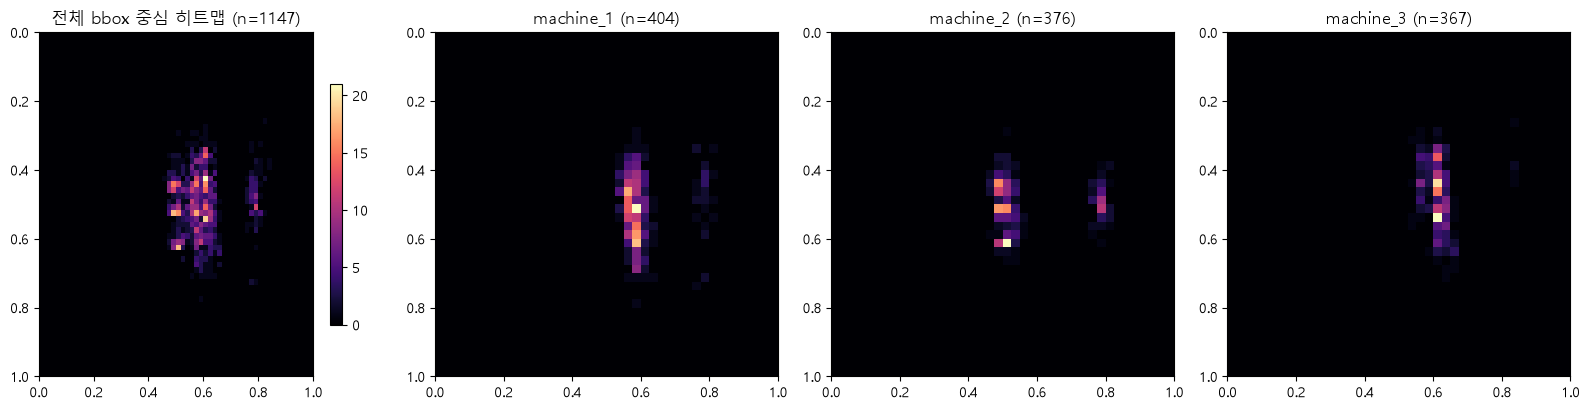

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
h = axes[0].hist2d(box_df["cx"], box_df["cy"], bins=60, range=[[0, 1], [0, 1]], cmap="magma")
axes[0].invert_yaxis()
axes[0].set_title(f"전체 bbox 중심 히트맵 (n={len(box_df)})")
fig.colorbar(h[3], ax=axes[0], shrink=0.7)

for ax, m in zip(axes[1:], ["machine_1", "machine_2", "machine_3"]):
    sub = box_df[box_df["machine"] == m]
    ax.hist2d(sub["cx"], sub["cy"], bins=40, range=[[0, 1], [0, 1]], cmap="magma")
    ax.invert_yaxis()
    ax.set_title(f"{m} (n={len(sub)})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_bbox_center_heatmap.png", dpi=120)
plt.show()


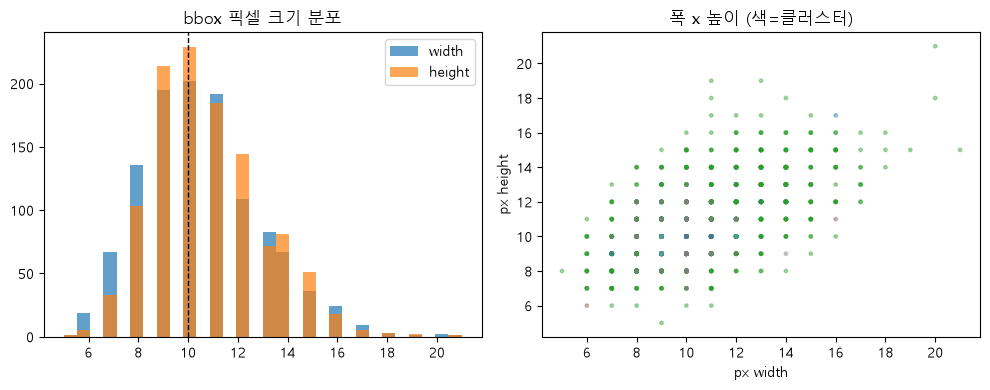

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(box_df["px_w"], bins=30, alpha=0.7, label="width")
axes[0].hist(box_df["px_h"], bins=30, alpha=0.7, label="height")
axes[0].axvline(geo["median_px_w"], color="k", ls="--", lw=1)
axes[0].set_title("bbox 픽셀 크기 분포")
axes[0].legend()
axes[1].scatter(box_df["px_w"], box_df["px_h"], s=6, alpha=0.4, c=box_df["cluster"], cmap="tab10")
axes[1].set_xlabel("px width")
axes[1].set_ylabel("px height")
axes[1].set_title("폭 x 높이 (색=클러스터)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_bbox_size_px.png", dpi=120)
plt.show()


In [20]:
# 한 이미지에 3개 bbox가 있을 때 세로 간격이 일정한지
three = label_summary[label_summary["n_boxes"] == 3]["stem"]
gaps1, gaps2 = [], []
for s in three:
    cys = sorted(label_boxes[label_boxes["stem"] == s]["cy"].tolist())
    gaps1.append(cys[1] - cys[0])
    gaps2.append(cys[2] - cys[1])
gaps1, gaps2 = np.array(gaps1), np.array(gaps2)
print("3-box 이미지 수:", len(three))
print("gap1(1->2) 평균/표준편차:", round(gaps1.mean(), 4), round(gaps1.std(), 4))
print("gap2(2->3) 평균/표준편차:", round(gaps2.mean(), 4), round(gaps2.std(), 4))
print("|gap1-gap2| 평균(0에 가까우면 등간격):", round(np.abs(gaps1 - gaps2).mean(), 4))


3-box 이미지 수: 323
gap1(1->2) 평균/표준편차: 0.0711 0.0048
gap2(2->3) 평균/표준편차: 0.0923 0.0093
|gap1-gap2| 평균(0에 가까우면 등간격): 0.0212


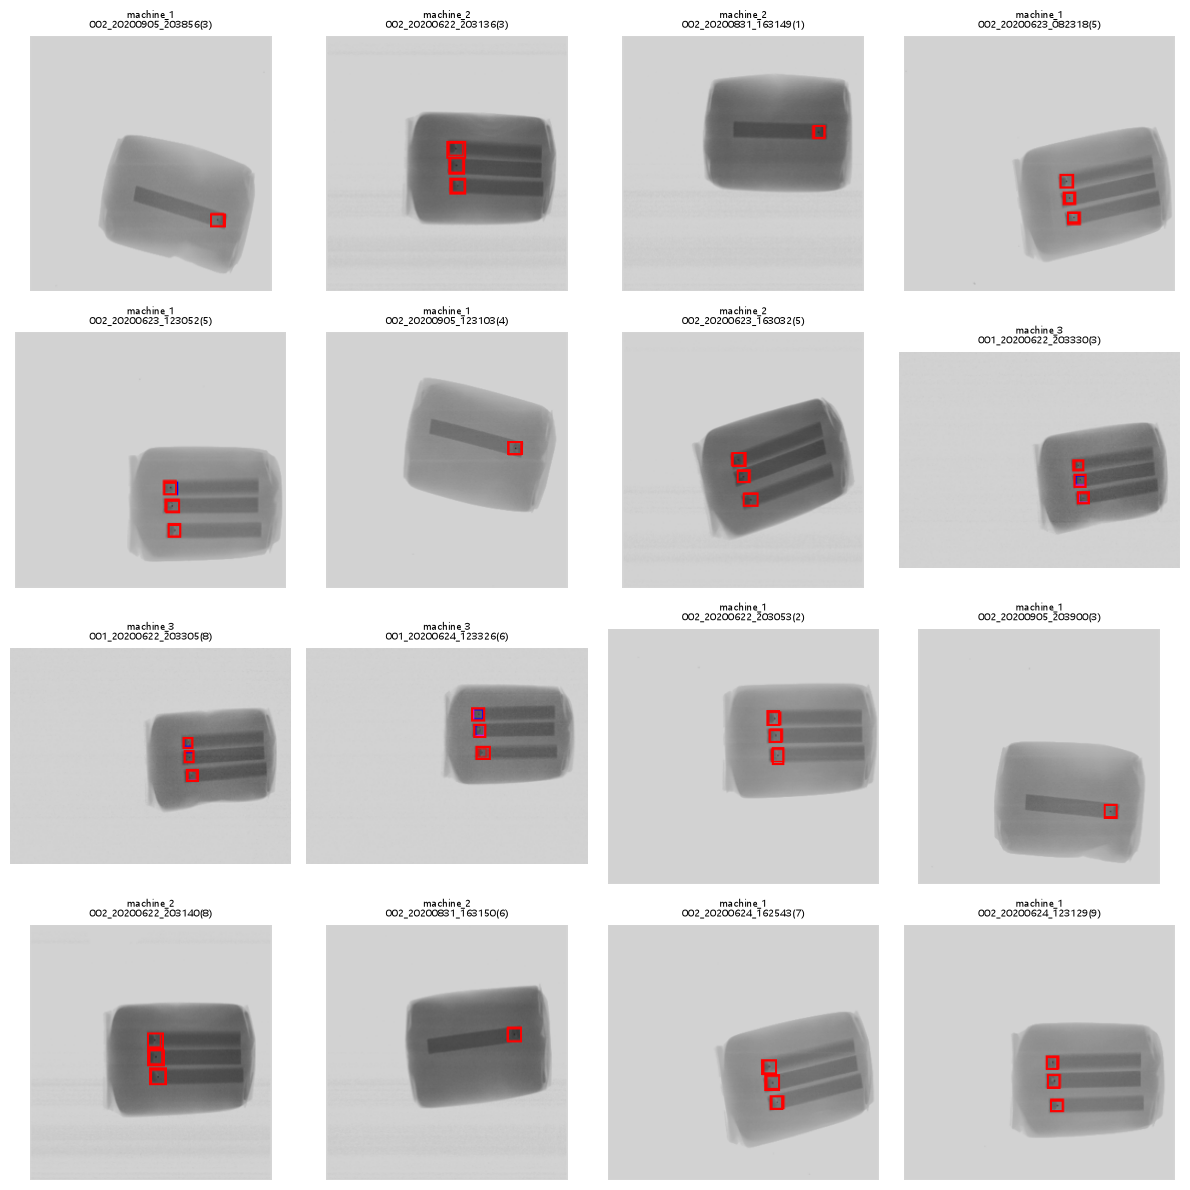

오버레이 샘플: ['002_20200905_203856(3)', '002_20200622_203136(3)', '002_20200831_163149(1)', '002_20200623_082318(5)', '002_20200623_123052(5)', '002_20200905_123103(4)', '002_20200623_163032(5)', '001_20200622_203330(3)', '001_20200622_203305(8)', '001_20200624_123326(6)', '002_20200622_203053(2)', '002_20200905_203900(3)', '002_20200622_203140(8)', '002_20200831_163150(6)', '002_20200624_162543(7)', '002_20200624_123129(9)']


In [21]:
def draw_overlay(stem, machine, max_side=256):
    p = dq._find_raw_bmp(ROOT, stem)
    with Image.open(p) as im:
        im = im.convert("RGB")
        w, h = im.size
        scale = max_side / max(w, h)
        im = im.resize((int(w * scale), int(h * scale)))
        draw = ImageDraw.Draw(im)
        for _, b in label_boxes[label_boxes["stem"] == stem].iterrows():
            x0 = (b["cx"] - b["w"] / 2) * w * scale
            y0 = (b["cy"] - b["h"] / 2) * h * scale
            x1 = (b["cx"] + b["w"] / 2) * w * scale
            y1 = (b["cy"] + b["h"] / 2) * h * scale
            draw.rectangle([x0 - 3, y0 - 3, x1 + 3, y1 + 3], outline=(255, 0, 0), width=2)
    return im


# 호기 x 클러스터 조합에서 골고루 16장 샘플
box_df["stem_machine"] = box_df["machine"]
combo = box_df.groupby(["machine", "cluster"])["stem"].apply(lambda s: s.drop_duplicates().tolist())
picks = []
rng = np.random.default_rng(0)
keys = list(combo.index)
rng.shuffle(keys)
i = 0
while len(picks) < 16 and keys:
    k = keys[i % len(keys)]
    stems_k = combo[k]
    cand = stems_k[len(picks) // len(keys) % len(stems_k)] if stems_k else None
    if cand and cand not in [p_ for p_, _ in picks]:
        picks.append((cand, k[0]))
    i += 1
    if i > 500:
        break
picks = picks[:16]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (stem, machine) in zip(axes.ravel(), picks):
    im = draw_overlay(stem, machine)
    ax.imshow(im)
    ax.set_title(f"{machine}\n{stem}", fontsize=7)
    ax.axis("off")
for ax in axes.ravel()[len(picks):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_label_overlay_grid.png", dpi=110)
plt.show()
print("오버레이 샘플:", [p for p, _ in picks])


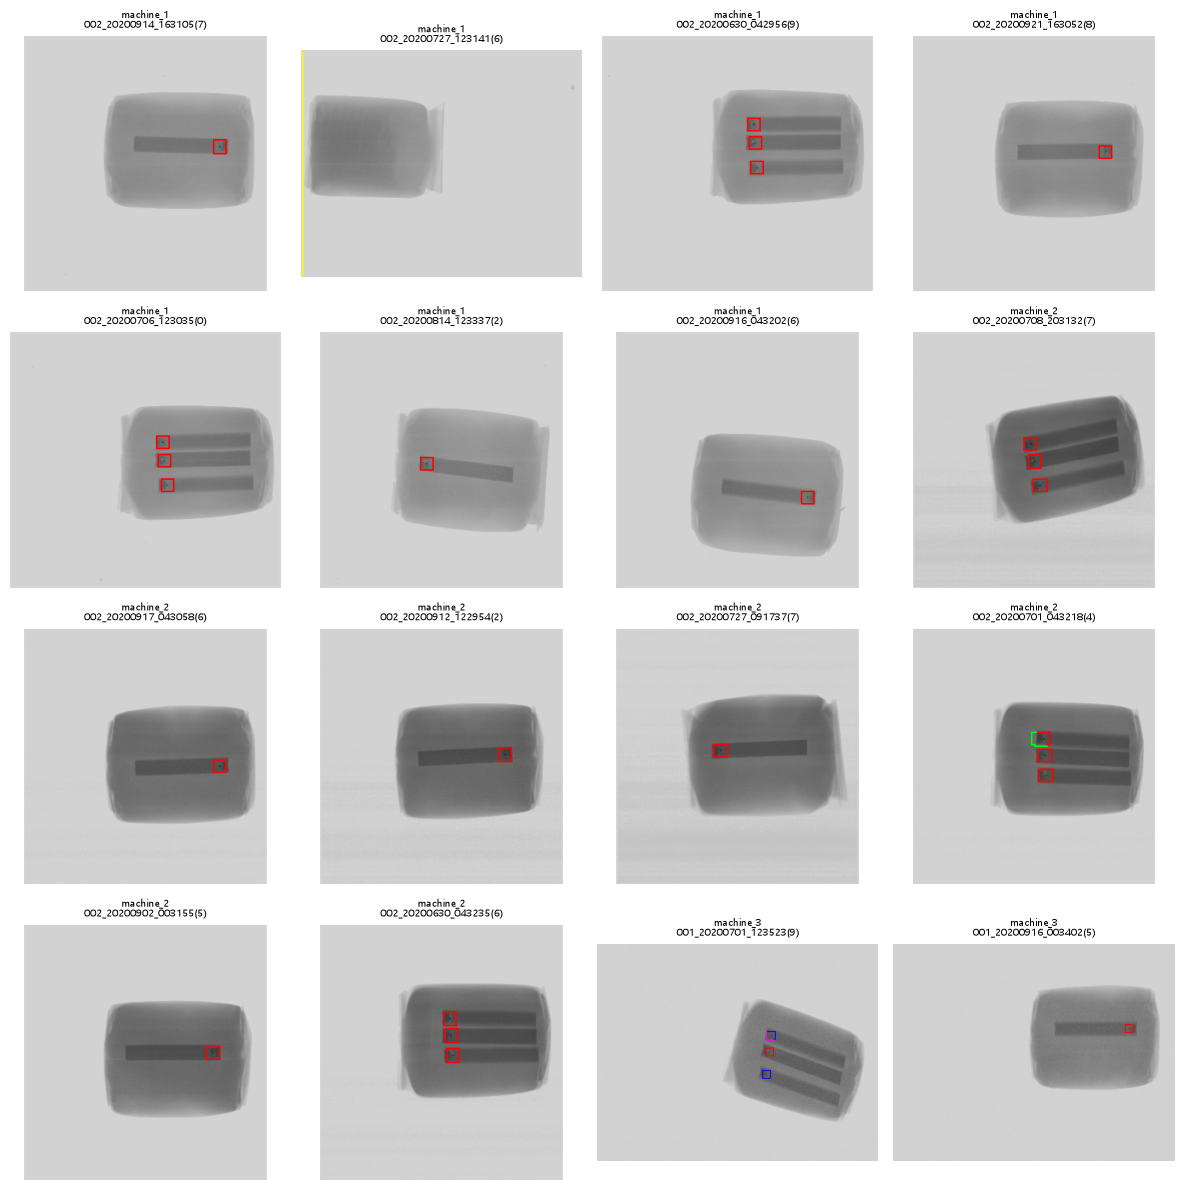

라벨 없는 원본 샘플: [(np.str_('002_20200914_163105(7)'), 'machine_1'), (np.str_('002_20200727_123141(6)'), 'machine_1'), (np.str_('002_20200630_042956(9)'), 'machine_1'), (np.str_('002_20200921_163052(8)'), 'machine_1'), (np.str_('002_20200706_123035(0)'), 'machine_1'), (np.str_('002_20200814_123337(2)'), 'machine_1'), (np.str_('002_20200916_043202(6)'), 'machine_1'), (np.str_('002_20200708_203132(7)'), 'machine_2'), (np.str_('002_20200917_043058(6)'), 'machine_2'), (np.str_('002_20200912_122954(2)'), 'machine_2'), (np.str_('002_20200727_091737(7)'), 'machine_2'), (np.str_('002_20200701_043218(4)'), 'machine_2'), (np.str_('002_20200902_003155(5)'), 'machine_2'), (np.str_('002_20200630_043235(6)'), 'machine_2'), (np.str_('001_20200701_123523(9)'), 'machine_3'), (np.str_('001_20200916_003402(5)'), 'machine_3')]


In [22]:
rng = np.random.default_rng(1)
per_machine = 16 // 3
picks_u = []
for m in ["machine_1", "machine_2", "machine_3"]:
    cand = index_df[(index_df["machine"] == m) & (~index_df["stem"].isin(label_stems))]["stem"].tolist()
    chosen = rng.choice(cand, size=min(per_machine + 2, len(cand)), replace=False)
    picks_u += [(s, m) for s in chosen]
picks_u = picks_u[:16]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (stem, m) in zip(axes.ravel(), picks_u):
    p = dq._find_raw_bmp(ROOT, stem)
    with Image.open(p) as im:
        im = im.convert("RGB")
    ax.imshow(im)
    ax.set_title(f"{m}\n{stem}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_unlabeled_grid.png", dpi=110)
plt.show()
print("라벨 없는 원본 샘플:", picks_u)


## 5-2. 검사기 오버레이 박스 (라벨 누수) — `overlay_boxes`

팔레트 인덱스 244~255(오버레이 마커)가 우연한 잡음이 아니라 **검사기 자체가 그려 넣은 탐지 박스**일 가능성을 검증한다: 마커 픽셀을 2회 팽창 후 연결요소로 묶어 바운딩박스를 만들고(가늘고 긴 테두리 아티팩트는 종횡비로 제외), YOLO 라벨 bbox와 위치가 겹치는지 본다.

In [23]:
ov_box_df, ov_summary_df = dq.overlay_boxes(
    ROOT, index_df, dilate=2, min_size=8,
    label_boxes=label_boxes, size_lookup=size_lookup,
)
print("오버레이 박스 총 개수:", len(ov_box_df), " / 이미지 수:", len(ov_summary_df))
print("\n이미지당 오버레이 박스 수 분포:")
print(ov_summary_df["n_overlay_boxes"].value_counts().sort_index())
print("\n호기별 이미지당 오버레이 박스 수:")
print(ov_summary_df.groupby("machine")["n_overlay_boxes"].value_counts().unstack(fill_value=0))


오버레이 박스 총 개수: 4071  / 이미지 수: 2529

이미지당 오버레이 박스 수 분포:
n_overlay_boxes
0     105
1    1395
2     411
3     618
Name: count, dtype: int64

호기별 이미지당 오버레이 박스 수:
n_overlay_boxes    0    1    2    3
machine                            
machine_1        105  482  201  155
machine_2          0  480  192  130
machine_3          0  433   18  333


In [24]:
print("오버레이 박스 픽셀 크기:")
print(ov_box_df[["width", "height"]].describe().round(2))
print("\n박스 종횡비(장변/단변) 최댓값(테두리 아티팩트 제외 후):",
      round((ov_box_df[["width", "height"]].max(axis=1) / ov_box_df[["width", "height"]].min(axis=1)).max(), 2))


오버레이 박스 픽셀 크기:
         width   height
count  4071.00  4071.00
mean     22.87    24.61
std       1.83     6.66
min      22.00    22.00
25%      22.00    22.00
50%      22.00    22.00
75%      24.00    24.00
max      44.00    68.00

박스 종횡비(장변/단변) 최댓값(테두리 아티팩트 제외 후): 2.18


In [25]:
# 이미지별로 사용된 팔레트 인덱스 조합(전체 박스 통합) 상위
pooled = ov_box_df.groupby("stem")["indices"].apply(lambda s: tuple(sorted({v for t in s for v in t})))
print("이미지별 사용 인덱스 조합 상위 10 (0건=오버레이 박스 없는 이미지):")
counts = pooled.value_counts()
zero_count = int((ov_summary_df["n_overlay_boxes"] == 0).sum())
combo = pd.concat([pd.Series({"()": zero_count}), counts.rename(index=str)]).sort_values(ascending=False)
print(combo.head(10).to_string())


이미지별 사용 인덱스 조합 상위 10 (0건=오버레이 박스 없는 이미지):
(255,)             1800
(254, 255)          150
(251, 254, 255)     139
()                  105
(252,)               95
(254,)               94
(253, 255)           31
(252, 255)           27
(251, 254)           22
(252, 254)           16


In [26]:
# YOLO 라벨 bbox 중심이 오버레이 박스 내부에 들어가는 비율
lab_ov = ov_summary_df[ov_summary_df["n_labels"] > 0]
n_labels_total = int(lab_ov["n_labels"].sum())
n_inside_total = int(lab_ov["n_inside"].sum())
print(f"라벨 bbox 총 {n_labels_total}개 중 오버레이 박스 내부: {n_inside_total}개 "
      f"({n_inside_total / n_labels_total:.4f})")
print("\n이미지당 (라벨 수 x 오버레이 박스 수) 교차표:")
print(lab_ov.groupby(["n_labels", "n_overlay_boxes"]).size())


라벨 bbox 총 1147개 중 오버레이 박스 내부: 1145개 (0.9983)

이미지당 (라벨 수 x 오버레이 박스 수) 교차표:
n_labels  n_overlay_boxes
1         1                  176
2         3                    1
3         1                    2
          2                  120
          3                  201
dtype: int64


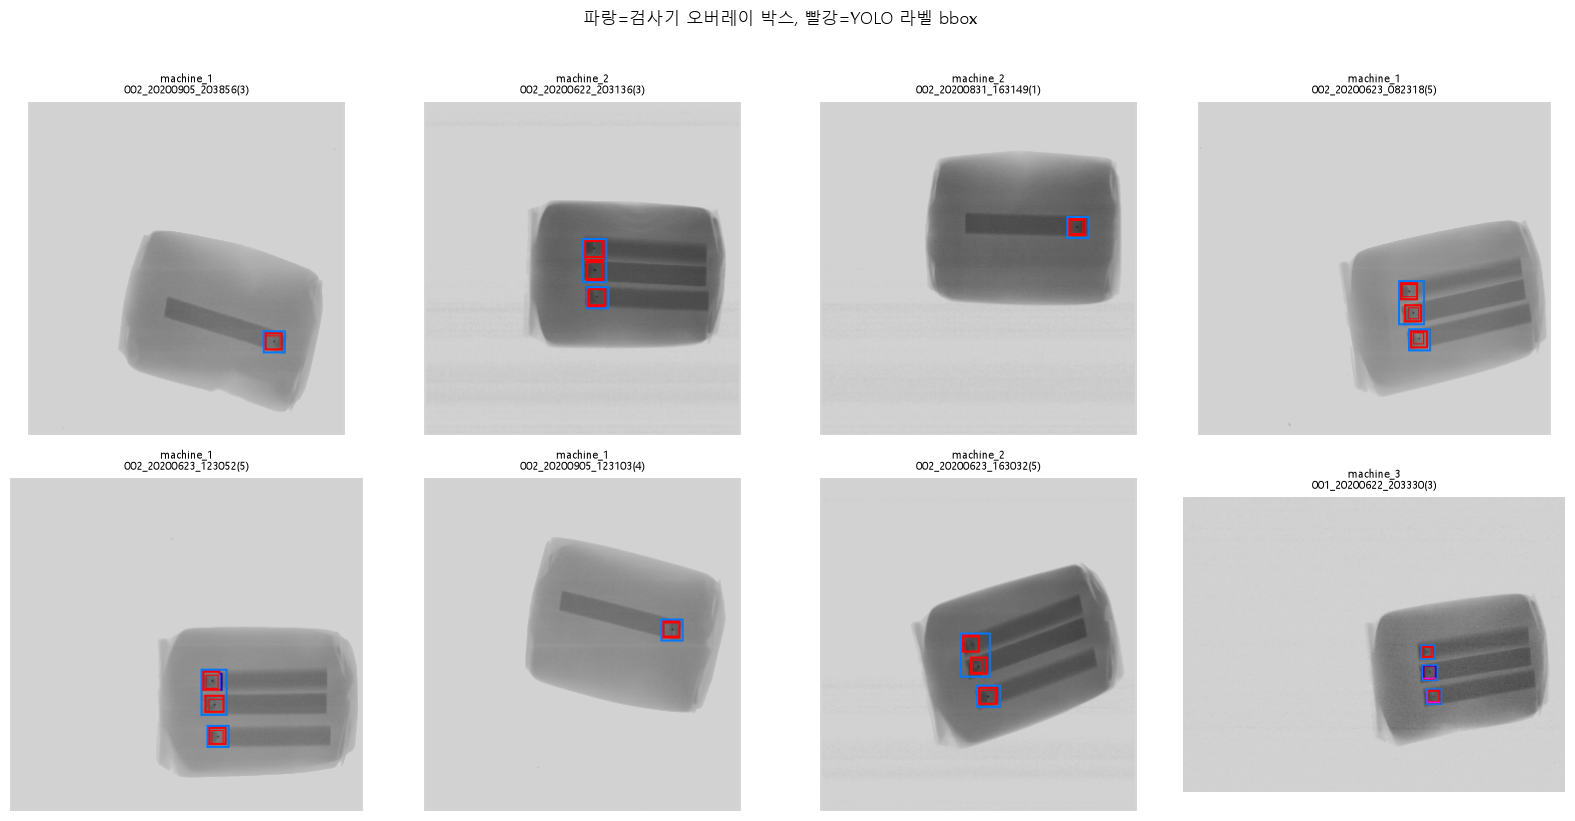

In [27]:
# 그림 1: 오버레이 박스(파랑) vs YOLO 라벨 bbox(빨강) 겹쳐 그리기 — 8장
def draw_overlay_vs_label(stem, machine):
    p = dq._find_raw_bmp(ROOT, stem)
    with Image.open(p) as im:
        im = im.convert("RGB")
    w, h = im.size
    draw = ImageDraw.Draw(im)
    for _, b in ov_box_df[ov_box_df["stem"] == stem].iterrows():
        draw.rectangle([b["xmin"], b["ymin"], b["xmax"], b["ymax"]], outline=(0, 120, 255), width=2)
    for _, b in label_boxes[label_boxes["stem"] == stem].iterrows():
        x0, y0 = (b["cx"] - b["w"] / 2) * w, (b["cy"] - b["h"] / 2) * h
        x1, y1 = (b["cx"] + b["w"] / 2) * w, (b["cy"] + b["h"] / 2) * h
        draw.rectangle([x0 - 2, y0 - 2, x1 + 2, y1 + 2], outline=(255, 0, 0), width=1)
    return im


sample8 = picks[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (stem, machine) in zip(axes.ravel(), sample8):
    ax.imshow(draw_overlay_vs_label(stem, machine))
    ax.set_title(f"{machine}\n{stem}", fontsize=8)
    ax.axis("off")
fig.suptitle("파랑=검사기 오버레이 박스, 빨강=YOLO 라벨 bbox", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_overlay_vs_label.png", dpi=110, bbox_inches="tight")
plt.show()


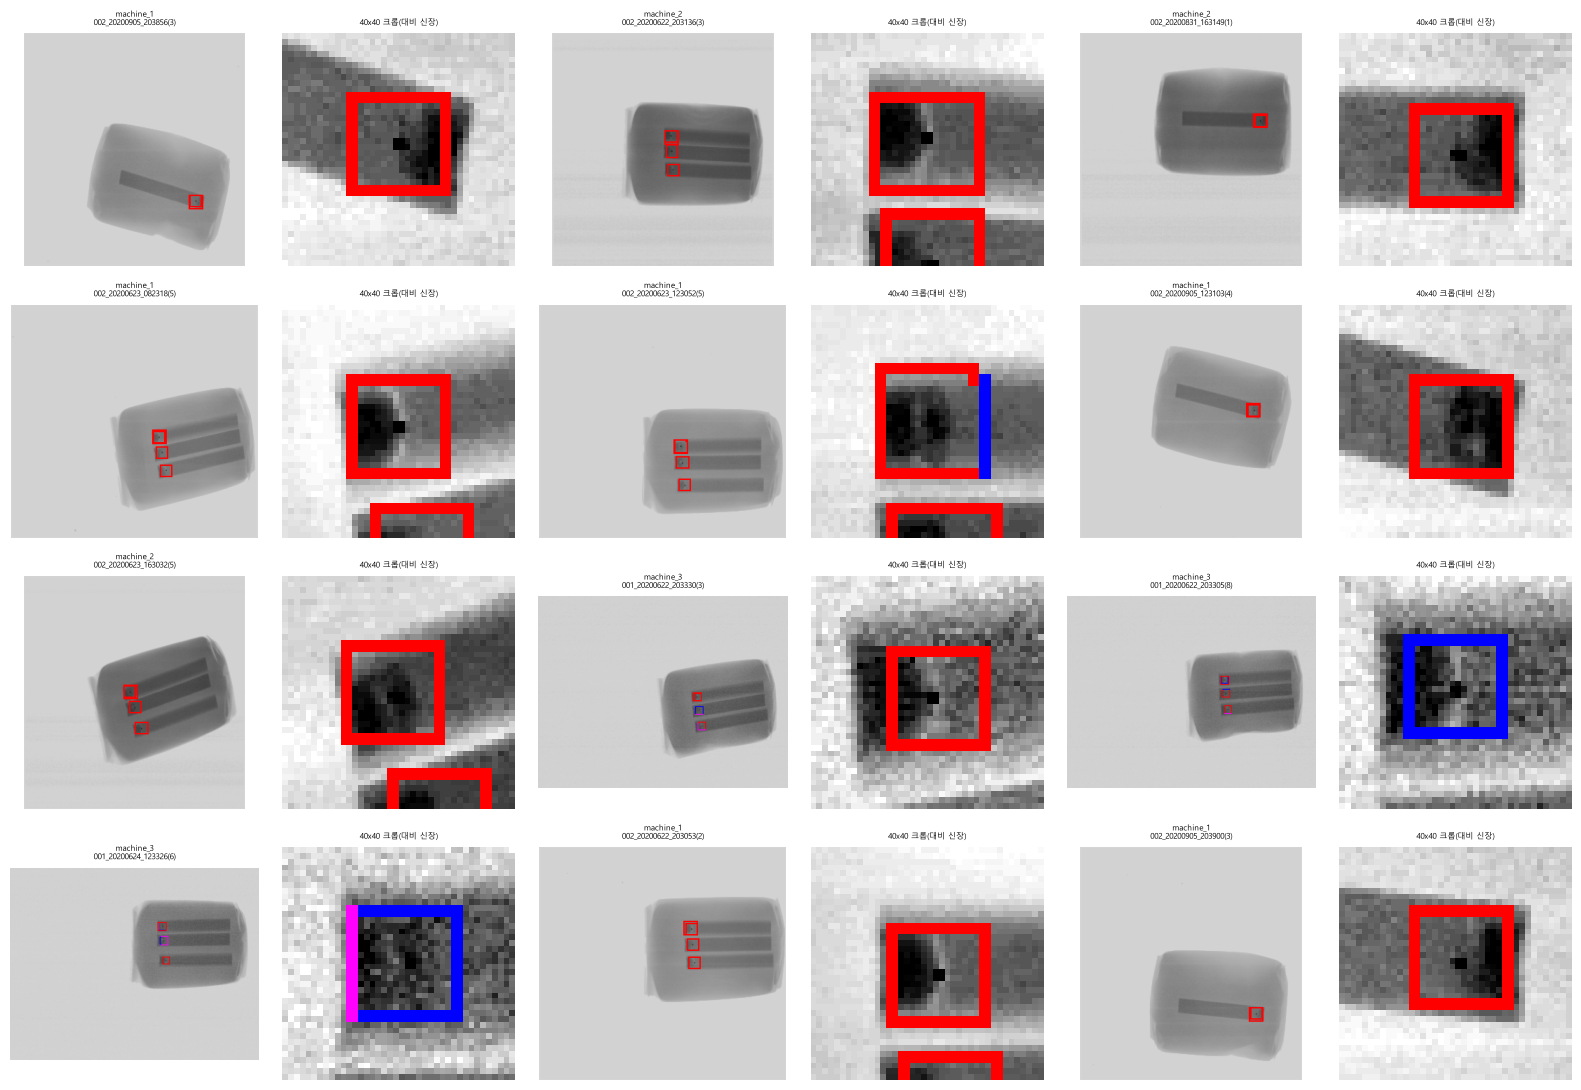

In [28]:
# 그림 2: 라벨 bbox 중심 40x40px 풀해상도 크롭(대비 신장) + 원본 축소본 나란히 — 12장
def contrast_crop(stem, cx, cy, half=20):
    p = dq._find_raw_bmp(ROOT, stem)
    with Image.open(p) as im:
        arr = np.asarray(im)
        pal = np.array(im.getpalette()).reshape(-1, 3)
    h, w = arr.shape
    px, py = int(cx * w), int(cy * h)
    x0, x1 = max(0, px - half), min(w, px + half)
    y0, y1 = max(0, py - half), min(h, py + half)
    crop = arr[y0:y1, x0:x1]
    gray_mask = crop < dq.MARKER_MIN_INDEX
    g = crop[gray_mask].astype(np.float64)
    lo, hi = np.percentile(g, 1), np.percentile(g, 99)
    stretched = np.clip((crop.astype(np.float64) - lo) / max(hi - lo, 1e-6), 0, 1) * 255
    rgb = np.stack([stretched] * 3, axis=-1).astype(np.uint8)
    rgb[~gray_mask] = pal[crop[~gray_mask]]
    return rgb


sample12 = picks[:12]
fig, axes = plt.subplots(4, 6, figsize=(16, 11))
for row in range(4):
    for col3 in range(3):
        i = row * 3 + col3
        if i >= len(sample12):
            break
        stem, machine = sample12[i]
        b0 = label_boxes[label_boxes["stem"] == stem].iloc[0]
        ax_orig, ax_crop = axes[row, col3 * 2], axes[row, col3 * 2 + 1]

        p = dq._find_raw_bmp(ROOT, stem)
        with Image.open(p) as im:
            im = im.convert("RGB")
        w, h = im.size
        draw = ImageDraw.Draw(im)
        cx_px, cy_px = b0["cx"] * w, b0["cy"] * h
        draw.rectangle([cx_px - 10, cy_px - 10, cx_px + 10, cy_px + 10], outline=(255, 0, 0), width=2)
        ax_orig.imshow(im)
        ax_orig.set_title(f"{machine}\n{stem}", fontsize=6)
        ax_orig.axis("off")

        crop_rgb = contrast_crop(stem, b0["cx"], b0["cy"], half=20)
        ax_crop.imshow(crop_rgb)
        ax_crop.set_title("40x40 크롭(대비 신장)", fontsize=6)
        ax_crop.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_bbox_crop_grid.png", dpi=110, bbox_inches="tight")
plt.show()


## 6. 라벨 세트의 대표성 (`label_coverage`)

In [29]:
cov = dq.label_coverage(index_df, label_stems)
print("호기별 라벨 유무 교차표")
print(cov["machine_table"])
print("chi2 =", round(cov["machine_chi2"], 3), " p =", cov["machine_p"], " dof =", cov["machine_dof"])
print()
print("일자(월)별 라벨 유무 교차표")
print(cov["date_table"])
print("chi2 =", round(cov["date_chi2"], 3), " p =", cov["date_p"], " dof =", cov["date_dof"])


호기별 라벨 유무 교차표
labeled    False  True 
machine                
machine_1    787    156
machine_2    628    177
machine_3    617    167
chi2 = 9.853  p = 0.007250367106197287  dof = 2

일자(월)별 라벨 유무 교차표
labeled   False  True 
date_bin              
2020-06     153    294
2020-07     799     42
2020-08     127     57
2020-09     953    107
chi2 = 789.951  p = 6.542062169183567e-171  dof = 3


In [30]:
def read_split(name):
    p = ROOT / "data_raw" / "reference" / "yolov3" / name
    stems = [Path(l.strip()).stem for l in p.read_text().splitlines() if l.strip()]
    return stems

train_stems = read_split("train.txt")
test_stems = read_split("test.txt")
print("참고 코드 train:", len(train_stems), " test:", len(test_stems))
print("train∩test:", len(set(train_stems) & set(test_stems)))

all_split_stems = train_stems + test_stems
fd = pd.Series(all_split_stems).map(stem_first["filename_date"])
ft = pd.Series(all_split_stems).map(stem_first["filename_time"])
t = pd.to_datetime(fd + ft, format="%Y%m%d%H%M%S")
split_df = pd.DataFrame({"stem": all_split_stems,
                          "split": ["train"] * len(train_stems) + ["test"] * len(test_stems),
                          "time": t.values}).sort_values("time")
split_df["gap_sec"] = split_df["time"].diff().dt.total_seconds()
print(split_df)


참고 코드 train: 12  test: 3
train∩test: 0
                      stem  split                time    gap_sec
12  001_20200622_203312(6)   test 2020-06-22 20:33:12        NaN
13  001_20200623_003516(8)   test 2020-06-23 00:35:16    14524.0
3   002_20200714_043029(1)  train 2020-07-14 04:30:29  1828513.0
4   002_20200715_042416(9)  train 2020-07-15 04:24:16    86027.0
5   002_20200831_083545(0)  train 2020-08-31 08:35:45  4075889.0
6   002_20200831_123134(5)  train 2020-08-31 12:31:34    14149.0
0   001_20200901_003429(1)  train 2020-09-01 00:34:29    43375.0
7   002_20200908_043137(8)  train 2020-09-08 04:31:37   619028.0
14  002_20200915_003459(4)   test 2020-09-15 00:34:59   590602.0
8   002_20200917_043110(7)  train 2020-09-17 04:31:10   186971.0
9   002_20200917_202952(6)  train 2020-09-17 20:29:52    57522.0
10  002_20200917_203001(5)  train 2020-09-17 20:30:01        9.0
11  002_20200922_083747(7)  train 2020-09-22 08:37:47   389266.0
1   001_20200922_163329(0)  train 2020-09-22 16:33:

## 7. 중복·근사 중복 (`near_duplicates`)

In [31]:
ssim_df = dq.near_duplicates(ROOT, index_df, sample_per_machine=1000)
print("계산된 인접 프레임 쌍 수:", len(ssim_df), " (추정 샘플 여부:", bool(ssim_df['estimated'].any()), ")")
print(ssim_df.groupby("machine")["ssim"].describe().round(3))
print("\nSSIM > 0.95 비율(전체):", round((ssim_df["ssim"] > 0.95).mean(), 4))
print("SSIM > 0.95 비율(호기별):")
print(ssim_df.groupby("machine").apply(lambda g: (g["ssim"] > 0.95).mean()).round(4))


계산된 인접 프레임 쌍 수: 2400  (추정 샘플 여부: False )
           count   mean    std    min    25%    50%    75%    max
machine                                                          
machine_1  898.0  0.904  0.032  0.833  0.880  0.898  0.919  0.999
machine_2  760.0  0.878  0.040  0.768  0.845  0.880  0.910  0.969
machine_3  742.0  0.864  0.028  0.777  0.846  0.866  0.883  0.927

SSIM > 0.95 비율(전체): 0.0471
SSIM > 0.95 비율(호기별):
machine
machine_1    0.1047
machine_2    0.0250
machine_3    0.0000
dtype: float64


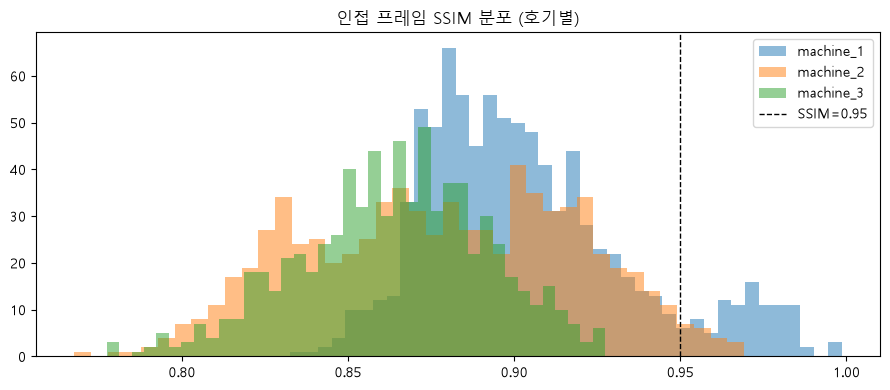

In [32]:
fig, ax = plt.subplots(figsize=(9, 4))
for m, g in ssim_df.groupby("machine"):
    ax.hist(g["ssim"], bins=40, alpha=0.5, label=m)
ax.axvline(0.95, color="k", ls="--", lw=1, label="SSIM=0.95")
ax.set_title("인접 프레임 SSIM 분포 (호기별)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_burst_ssim.png", dpi=120)
plt.show()


## 8. 불균형·문제 정의 정리

In [33]:
n_with_box = label_summary["n_boxes"].gt(0).sum()
n_zero_box = (label_summary["n_boxes"] == 0).sum()
print("bbox>=1 라벨 이미지:", n_with_box, " / bbox=0 라벨 이미지:", n_zero_box)
print("전체 2,532장 중 라벨 있음:", len(label_stems), " 라벨 없음:", len(index_df) - len(label_stems))
print("(주의: 라벨 없음 != 이물 없음. 전량 NG 판정 영상이라 OK 기준 영상이 없음)")


bbox>=1 라벨 이미지: 500  / bbox=0 라벨 이미지: 0
전체 2,532장 중 라벨 있음: 500  라벨 없음: 2032
(주의: 라벨 없음 != 이물 없음. 전량 NG 판정 영상이라 OK 기준 영상이 없음)


## 9. 필요 처리 표 + 총평

(리포트 `reports/01_data_quality.md`에 정리)